# 3.7 Dimension-Factor Correlation Analysis

This notebook identifies which latent dimensions are most strongly correlated with specific factors:
- **Age**: Continuous variable
- **Sex**: Binary variable (0=Female, 1=Male)
- **Handedness**: Categorical variable (1=Right, 2=Left)
- **Scanner**: Categorical variable (Manufacturer)
- **SBR**: Continuous variable (using SBR_PC1 as primary pathology measure)

## Objective
For each factor, identify:
1. The **single dimension** with the highest correlation
2. The **separation gap** between the top dimension and the 2nd-best dimension
3. Whether this top dimension is well-separated (indicating a clear signal)

## Methods
- **Pearson correlation**: For continuous variables (Age, SBR_PC1)
- **Point-biserial correlation**: For binary variables (Sex)
- **Eta-squared (η²)**: For categorical variables (Handedness, Scanner)
- **Separation metric**: Gap between 1st and 2nd ranked correlations

## Section 1: Setup and Data Loading

### 1.1 Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import re
from scipy import stats
from scipy.stats import pointbiserialr
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from datetime import datetime

import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
pd.set_option('display.max_columns', None)

print("Libraries imported successfully!")

Libraries imported successfully!


### 1.2 Define Constants

In [2]:
FEATURE_COLS = [f'latent_{i}' for i in range(256)]
SBR_COLS = [
    'DATSCAN_CAUDATE_R', 'DATSCAN_CAUDATE_L',
    'DATSCAN_PUTAMEN_R', 'DATSCAN_PUTAMEN_L',
    'DATSCAN_PUTAMEN_R_ANT', 'DATSCAN_PUTAMEN_L_ANT'
]

RANDOM_STATE = 42

print(f"Number of latent dimensions: {len(FEATURE_COLS)}")

Number of latent dimensions: 256


### 1.3 Load and Merge All Data

In [3]:
df_combined = pd.read_csv('output/final_train_combined_vae_data.csv')

print(f"Combined dataset shape: {df_combined.shape}")
print(f"Unique patients in combined data: {df_combined['PATNO'].nunique()}")

# Check for multiple visits per patient
visits_per_patient = df_combined.groupby('PATNO').size()
print(f"\nVisits per patient statistics:")
print(visits_per_patient.describe())
print(f"Patients with multiple visits: {(visits_per_patient > 1).sum()}")

Combined dataset shape: (2373, 303)
Unique patients in combined data: 1437

Visits per patient statistics:
count    1437.000000
mean        1.651357
std         0.955241
min         1.000000
25%         1.000000
50%         1.000000
75%         2.000000
max         5.000000
dtype: float64
Patients with multiple visits: 553


### 1.4 Calculate SBR Principal Components

In [4]:
# Filter to rows with complete SBR data
df_with_sbr = df_combined.dropna(subset=SBR_COLS).copy()
print(f"Rows with complete SBR data: {len(df_with_sbr)}")

# Standardize and apply PCA
scaler_sbr = StandardScaler()
sbr_scaled = scaler_sbr.fit_transform(df_with_sbr[SBR_COLS])
pca = PCA(n_components=3, random_state=RANDOM_STATE)
sbr_pcs = pca.fit_transform(sbr_scaled)

df_with_sbr['SBR_PC1'] = sbr_pcs[:, 0]
df_with_sbr['SBR_PC2'] = sbr_pcs[:, 1]
df_with_sbr['SBR_PC3'] = sbr_pcs[:, 2]

print(f"\nSBR PCA explained variance: {pca.explained_variance_ratio_}")
print(f"Total variance explained: {pca.explained_variance_ratio_.sum():.2%}")

# Use this as final dataset
df_final = df_with_sbr.reset_index(drop=True)
print(f"\nFinal dataset: {df_final.shape}")
print(f"Unique patients: {df_final['PATNO'].nunique()}")

Rows with complete SBR data: 2373

SBR PCA explained variance: [0.88338287 0.05277345 0.04814441]
Total variance explained: 98.43%

Final dataset: (2373, 306)
Unique patients: 1437


### 1.5 Check Available Factors

In [5]:
print("Factor Availability Check:")
print("="*80)

# Age
age_available = df_final['AGE_AT_VISIT'].notna().sum()
print(f"\nAge (AGE_AT_VISIT):")
print(f"  Available: {age_available}/{len(df_final)} ({age_available/len(df_final)*100:.1f}%)")
if age_available > 0:
    print(f"  Range: [{df_final['AGE_AT_VISIT'].min():.0f}, {df_final['AGE_AT_VISIT'].max():.0f}]")
    print(f"  Mean: {df_final['AGE_AT_VISIT'].mean():.1f}")

# Sex
sex_available = df_final['SEX'].notna().sum()
print(f"\nSex:")
print(f"  Available: {sex_available}/{len(df_final)} ({sex_available/len(df_final)*100:.1f}%)")
if sex_available > 0:
    print(f"  Distribution:\n{df_final['SEX'].value_counts()}")

# Handedness
handed_available = df_final['HANDED'].notna().sum()
print(f"\nHandedness:")
print(f"  Available: {handed_available}/{len(df_final)} ({handed_available/len(df_final)*100:.1f}%)")
if handed_available > 0:
    print(f"  Distribution:\n{df_final['HANDED'].value_counts()}")


# Scanner
scanner_available = df_final['Manufacturer'].notna().sum()
print(f"\nScanner (Manufacturer):")
print(f"  Available: {scanner_available}/{len(df_final)} ({scanner_available/len(df_final)*100:.1f}%)")
if scanner_available > 0:
    print(f"  Unique manufacturers: {df_final['Manufacturer'].nunique()}")
    print(f"  Top 5:\n{df_final['Manufacturer'].value_counts().head()}")

# SBR
sbr_available = df_final['SBR_PC1'].notna().sum()
print(f"\nSBR (SBR_PC1):")
print(f"  Available: {sbr_available}/{len(df_final)} ({sbr_available/len(df_final)*100:.1f}%)")
if sbr_available > 0:
    print(f"  Range: [{df_final['SBR_PC1'].min():.2f}, {df_final['SBR_PC1'].max():.2f}]")
    print(f"  Mean: {df_final['SBR_PC1'].mean():.2f}")

Factor Availability Check:

Age (AGE_AT_VISIT):
  Available: 2371/2373 (99.9%)
  Range: [29, 89]
  Mean: 63.4

Sex:
  Available: 2371/2373 (99.9%)
  Distribution:
SEX
1.0    1483
0.0     888
Name: count, dtype: int64

Handedness:
  Available: 2370/2373 (99.9%)
  Distribution:
HANDED
1.0    2055
2.0     241
3.0      74
Name: count, dtype: int64

Scanner (Manufacturer):
  Available: 2372/2373 (100.0%)
  Unique manufacturers: 16
  Top 5:
Manufacturer
SIEMENS NM                              1173
GE MEDICAL SYSTEMS                       470
Marconi Medical Systems, NM Division     258
PICKER                                   130
Philips Nuclear Medicine                 101
Name: count, dtype: int64

SBR (SBR_PC1):
  Available: 2373/2373 (100.0%)
  Range: [-4.52, 11.08]
  Mean: -0.00


## Section 2: Correlation Analysis Functions

### 2.1 Define Correlation Functions

In [6]:
def compute_continuous_correlations(X, y, feature_names):
    """
    Compute Pearson correlations between features (X) and continuous target (y).
    Returns DataFrame with correlations, p-values, and absolute correlations.
    """
    results = []
    
    for i, feature in enumerate(feature_names):
        # Remove NaN pairs
        mask = ~(np.isnan(X[:, i]) | np.isnan(y))
        if mask.sum() < 3:
            continue
            
        r, p = stats.pearsonr(X[mask, i], y[mask])
        results.append({
            'Feature': feature,
            'Correlation': r,
            'P_Value': p,
            'Abs_Correlation': abs(r)
        })
    
    df_results = pd.DataFrame(results)
    df_results = df_results.sort_values('Abs_Correlation', ascending=False).reset_index(drop=True)
    df_results['Rank'] = range(1, len(df_results) + 1)
    
    return df_results


def compute_binary_correlations(X, y, feature_names):
    """
    Compute point-biserial correlations between features (X) and binary target (y).
    Returns DataFrame with correlations, p-values, and absolute correlations.
    """
    results = []
    
    for i, feature in enumerate(feature_names):
        # Remove NaN pairs
        mask = ~(np.isnan(X[:, i]) | np.isnan(y))
        if mask.sum() < 3:
            continue
            
        r, p = pointbiserialr(y[mask], X[mask, i])
        results.append({
            'Feature': feature,
            'Correlation': r,
            'P_Value': p,
            'Abs_Correlation': abs(r)
        })
    
    df_results = pd.DataFrame(results)
    df_results = df_results.sort_values('Abs_Correlation', ascending=False).reset_index(drop=True)
    df_results['Rank'] = range(1, len(df_results) + 1)
    
    return df_results


def compute_categorical_associations(X, y, feature_names):
    """
    Compute eta-squared (η²) for association between features (X) and categorical target (y).
    η² represents the proportion of variance in the feature explained by the category.
    Returns DataFrame with eta-squared values.
    """
    results = []
    
    for i, feature in enumerate(feature_names):
        # Remove NaN pairs
        mask = ~(np.isnan(X[:, i]) | pd.isna(y))
        if mask.sum() < 3:
            continue
        
        x_clean = X[mask, i]
        y_clean = y[mask]
        
        # Get unique categories
        categories = np.unique(y_clean)
        if len(categories) < 2:
            continue
        
        # Compute ANOVA
        groups = [x_clean[y_clean == cat] for cat in categories]
        f_stat, p_val = stats.f_oneway(*groups)
        
        # Compute eta-squared
        grand_mean = x_clean.mean()
        ss_between = sum(len(g) * (g.mean() - grand_mean)**2 for g in groups)
        ss_total = sum((x_clean - grand_mean)**2)
        eta_squared = ss_between / ss_total if ss_total > 0 else 0
        
        results.append({
            'Feature': feature,
            'Eta_Squared': eta_squared,
            'F_Statistic': f_stat,
            'P_Value': p_val
        })
    
    df_results = pd.DataFrame(results)
    df_results = df_results.sort_values('Eta_Squared', ascending=False).reset_index(drop=True)
    df_results['Rank'] = range(1, len(df_results) + 1)
    
    return df_results


print("Correlation functions defined successfully!")

Correlation functions defined successfully!


### 2.2 Define Separation Analysis Function

In [7]:
def analyze_separation(df_corr, metric_col='Abs_Correlation', top_n=10):
    """
    Analyze separation between top-ranked features.
    Returns summary statistics and separation gap.
    """
    if len(df_corr) < 2:
        return None
    
    top_feature = df_corr.iloc[0]
    second_feature = df_corr.iloc[1]
    
    gap = top_feature[metric_col] - second_feature[metric_col]
    gap_pct = (gap / top_feature[metric_col] * 100) if top_feature[metric_col] > 0 else 0
    
    summary = {
        'Top_Feature': top_feature['Feature'],
        'Top_Value': top_feature[metric_col],
        'Second_Feature': second_feature['Feature'],
        'Second_Value': second_feature[metric_col],
        'Gap': gap,
        'Gap_Percent': gap_pct,
        'Top_N_Features': df_corr.head(top_n)['Feature'].tolist(),
        'Top_N_Values': df_corr.head(top_n)[metric_col].tolist()
    }
    
    return summary


print("Separation analysis function defined!")

Separation analysis function defined!


## Section 3: Factor-by-Factor Analysis

### 3.1 Extract Latent Features

In [8]:
# Extract latent features matrix
X_latent = df_final[FEATURE_COLS].values
print(f"Latent features matrix shape: {X_latent.shape}")
print(f"Missing values: {np.isnan(X_latent).sum()}")

Latent features matrix shape: (2373, 256)
Missing values: 0


### 3.2 Age Analysis

In [9]:
print("="*80)
print("FACTOR 1: AGE")
print("="*80)

y_age = df_final['AGE_AT_VISIT'].values
print(f"\nSamples with valid age: {(~np.isnan(y_age)).sum()}")

# Compute correlations
df_age_corr = compute_continuous_correlations(X_latent, y_age, FEATURE_COLS)

# Analyze separation
age_sep = analyze_separation(df_age_corr, metric_col='Abs_Correlation', top_n=10)

print(f"\nTop dimension: {age_sep['Top_Feature']}")
print(f"  Correlation: {age_sep['Top_Value']:.4f}")
print(f"  P-value: {df_age_corr.iloc[0]['P_Value']:.4e}")

print(f"\nSecond-best dimension: {age_sep['Second_Feature']}")
print(f"  Correlation: {age_sep['Second_Value']:.4f}")

print(f"\nSeparation Gap:")
print(f"  Absolute: {age_sep['Gap']:.4f}")
print(f"  Relative: {age_sep['Gap_Percent']:.1f}%")

print(f"\nTop 10 dimensions:")
print(df_age_corr.head(10)[['Rank', 'Feature', 'Correlation', 'Abs_Correlation', 'P_Value']].to_string(index=False))

FACTOR 1: AGE

Samples with valid age: 2371

Top dimension: latent_72
  Correlation: 0.3068
  P-value: 7.7602e-53

Second-best dimension: latent_116
  Correlation: 0.2953

Separation Gap:
  Absolute: 0.0114
  Relative: 3.7%

Top 10 dimensions:
 Rank    Feature  Correlation  Abs_Correlation      P_Value
    1  latent_72    -0.306751         0.306751 7.760217e-53
    2 latent_116     0.295325         0.295325 6.277702e-49
    3 latent_108     0.280222         0.280222 4.968214e-44
    4 latent_231     0.275877         0.275877 1.121694e-42
    5 latent_191     0.266294         0.266294 8.910289e-40
    6 latent_175    -0.246701         0.246701 3.295166e-34
    7  latent_14    -0.235817         0.235817 2.546149e-31
    8  latent_27     0.231698         0.231698 2.893990e-30
    9 latent_133    -0.228920         0.228920 1.451188e-29
   10 latent_163     0.227621         0.227621 3.062365e-29


### 3.3 Sex Analysis

In [10]:
print("\n" + "="*80)
print("FACTOR 2: SEX")
print("="*80)

y_sex = df_final['SEX'].values
print(f"\nSamples with valid sex: {(~np.isnan(y_sex)).sum()}")
print(f"Distribution: Female={(y_sex==0).sum()}, Male={(y_sex==1).sum()}")

# Compute correlations
df_sex_corr = compute_binary_correlations(X_latent, y_sex, FEATURE_COLS)

# Analyze separation
sex_sep = analyze_separation(df_sex_corr, metric_col='Abs_Correlation', top_n=10)

print(f"\nTop dimension: {sex_sep['Top_Feature']}")
print(f"  Correlation: {sex_sep['Top_Value']:.4f}")
print(f"  P-value: {df_sex_corr.iloc[0]['P_Value']:.4e}")

print(f"\nSecond-best dimension: {sex_sep['Second_Feature']}")
print(f"  Correlation: {sex_sep['Second_Value']:.4f}")

print(f"\nSeparation Gap:")
print(f"  Absolute: {sex_sep['Gap']:.4f}")
print(f"  Relative: {sex_sep['Gap_Percent']:.1f}%")

print(f"\nTop 10 dimensions:")
print(df_sex_corr.head(10)[['Rank', 'Feature', 'Correlation', 'Abs_Correlation', 'P_Value']].to_string(index=False))


FACTOR 2: SEX

Samples with valid sex: 2371
Distribution: Female=888, Male=1483

Top dimension: latent_133
  Correlation: 0.2500
  P-value: 4.2107e-35

Second-best dimension: latent_10
  Correlation: 0.2150

Separation Gap:
  Absolute: 0.0350
  Relative: 14.0%

Top 10 dimensions:
 Rank    Feature  Correlation  Abs_Correlation      P_Value
    1 latent_133    -0.249962         0.249962 4.210676e-35
    2  latent_10    -0.215004         0.215004 3.398813e-26
    3 latent_185    -0.207458         0.207458 1.832025e-24
    4  latent_72    -0.203020         0.203020 1.781013e-23
    5 latent_254    -0.191556         0.191556 4.971311e-21
    6 latent_134    -0.185669         0.185669 7.839369e-20
    7 latent_118    -0.173104         0.173104 2.090681e-17
    8  latent_50    -0.170206         0.170206 7.156983e-17
    9 latent_223     0.164824         0.164824 6.647281e-16
   10 latent_120    -0.154143         0.154143 4.459014e-14


### 3.4 Handedness Analysis

In [11]:
print("\n" + "="*80)
print("FACTOR 3: HANDEDNESS")
print("="*80)

y_hand = df_final["HANDED"].values
valid_hand = pd.notna(y_hand)
print(f"\nSamples with valid handedness: {valid_hand.sum()}")

if valid_hand.sum() > 0:
    print(f"Distribution:\n{pd.Series(y_hand).value_counts()}")
    
    # Categorical - use eta-squared
    print("\nTreating as categorical variable...")
    df_hand_corr = compute_categorical_associations(X_latent, y_hand, FEATURE_COLS)
    metric_col = 'Eta_Squared'
    
    # Analyze separation
    hand_sep = analyze_separation(df_hand_corr, metric_col=metric_col, top_n=10)
    
    print(f"\nTop dimension: {hand_sep['Top_Feature']}")
    print(f"  {metric_col}: {hand_sep['Top_Value']:.4f}")
    print(f"  P-value: {df_hand_corr.iloc[0]['P_Value']:.4e}")
    
    print(f"\nSecond-best dimension: {hand_sep['Second_Feature']}")
    print(f"  {metric_col}: {hand_sep['Second_Value']:.4f}")
    
    print(f"\nSeparation Gap:")
    print(f"  Absolute: {hand_sep['Gap']:.4f}")
    print(f"  Relative: {hand_sep['Gap_Percent']:.1f}%")
    
    print(f"\nTop 10 dimensions:")
    print(df_hand_corr.head(10).to_string(index=False))


FACTOR 3: HANDEDNESS

Samples with valid handedness: 2370
Distribution:
1.0    2055
2.0     241
3.0      74
Name: count, dtype: int64

Treating as categorical variable...

Top dimension: latent_142
  Eta_Squared: 0.0064
  P-value: 5.0812e-04

Second-best dimension: latent_207
  Eta_Squared: 0.0058

Separation Gap:
  Absolute: 0.0006
  Relative: 9.2%

Top 10 dimensions:
   Feature  Eta_Squared  F_Statistic  P_Value  Rank
latent_142     0.006388     7.609157 0.000508     1
latent_207     0.005800     6.904902 0.001023     2
latent_157     0.005559     6.615452 0.001364     3
latent_251     0.005464     6.502723 0.001526     4
 latent_95     0.004776     5.680046 0.003460     5
 latent_77     0.004531     5.386429 0.004635     6
 latent_34     0.004396     5.225154 0.005442     7
latent_228     0.004333     5.150388 0.005862     8
 latent_70     0.003811     4.527352 0.010903     9
 latent_98     0.003764     4.472043 0.011521    10


### 3.5 Scanner Analysis

In [12]:
print("\n" + "="*80)
print("FACTOR 4: SCANNER (Manufacturer)")
print("="*80)

y_scanner = df_final['Manufacturer'].values
valid_scanner = pd.notna(y_scanner)
print(f"\nSamples with valid scanner: {valid_scanner.sum()}")
print(f"Unique manufacturers: {pd.Series(y_scanner).nunique()}")
print(f"\nTop 5 manufacturers:\n{pd.Series(y_scanner).value_counts().head()}")

# Compute eta-squared
df_scanner_corr = compute_categorical_associations(X_latent, y_scanner, FEATURE_COLS)

# Analyze separation
scanner_sep = analyze_separation(df_scanner_corr, metric_col='Eta_Squared', top_n=10)

print(f"\nTop dimension: {scanner_sep['Top_Feature']}")
print(f"  Eta-squared: {scanner_sep['Top_Value']:.4f}")
print(f"  P-value: {df_scanner_corr.iloc[0]['P_Value']:.4e}")

print(f"\nSecond-best dimension: {scanner_sep['Second_Feature']}")
print(f"  Eta-squared: {scanner_sep['Second_Value']:.4f}")

print(f"\nSeparation Gap:")
print(f"  Absolute: {scanner_sep['Gap']:.4f}")
print(f"  Relative: {scanner_sep['Gap_Percent']:.1f}%")

print(f"\nTop 10 dimensions:")
print(df_scanner_corr.head(10).to_string(index=False))


FACTOR 4: SCANNER (Manufacturer)

Samples with valid scanner: 2372
Unique manufacturers: 16

Top 5 manufacturers:
SIEMENS NM                              1173
GE MEDICAL SYSTEMS                       470
Marconi Medical Systems, NM Division     258
PICKER                                   130
Philips Nuclear Medicine                 101
Name: count, dtype: int64

Top dimension: latent_39
  Eta-squared: 0.1784
  P-value: 2.1929e-89

Second-best dimension: latent_213
  Eta-squared: 0.1734

Separation Gap:
  Absolute: 0.0049
  Relative: 2.8%

Top 10 dimensions:
   Feature  Eta_Squared  F_Statistic      P_Value  Rank
 latent_39     0.178356    34.094848 2.192907e-89     1
latent_213     0.173431    32.955709 2.089829e-86     2
latent_126     0.119255    21.267107 5.598910e-55     3
latent_134     0.118883    21.191941 9.016604e-55     4
 latent_73     0.110882    19.587757 2.424765e-50     5
latent_231     0.110602    19.532275 3.453883e-50     6
latent_160     0.098182    17.099974 1.995

### 3.6 SBR Analysis

In [13]:
print("\n" + "="*80)
print("FACTOR 5: SBR (SBR_PC1)")
print("="*80)

y_sbr = df_final['SBR_PC1'].values
print(f"\nSamples with valid SBR: {(~np.isnan(y_sbr)).sum()}")
print(f"SBR_PC1 range: [{np.nanmin(y_sbr):.2f}, {np.nanmax(y_sbr):.2f}]")
print(f"SBR_PC1 mean: {np.nanmean(y_sbr):.2f}")

# Compute correlations
df_sbr_corr = compute_continuous_correlations(X_latent, y_sbr, FEATURE_COLS)

# Analyze separation
sbr_sep = analyze_separation(df_sbr_corr, metric_col='Abs_Correlation', top_n=10)

print(f"\nTop dimension: {sbr_sep['Top_Feature']}")
print(f"  Correlation: {sbr_sep['Top_Value']:.4f}")
print(f"  P-value: {df_sbr_corr.iloc[0]['P_Value']:.4e}")

print(f"\nSecond-best dimension: {sbr_sep['Second_Feature']}")
print(f"  Correlation: {sbr_sep['Second_Value']:.4f}")

print(f"\nSeparation Gap:")
print(f"  Absolute: {sbr_sep['Gap']:.4f}")
print(f"  Relative: {sbr_sep['Gap_Percent']:.1f}%")

print(f"\nTop 10 dimensions:")
print(df_sbr_corr.head(10)[['Rank', 'Feature', 'Correlation', 'Abs_Correlation', 'P_Value']].to_string(index=False))


FACTOR 5: SBR (SBR_PC1)

Samples with valid SBR: 2373
SBR_PC1 range: [-4.52, 11.08]
SBR_PC1 mean: -0.00

Top dimension: latent_126
  Correlation: 0.9146
  P-value: 0.0000e+00

Second-best dimension: latent_135
  Correlation: 0.4489

Separation Gap:
  Absolute: 0.4657
  Relative: 50.9%

Top 10 dimensions:
 Rank    Feature  Correlation  Abs_Correlation       P_Value
    1 latent_126    -0.914637         0.914637  0.000000e+00
    2 latent_135    -0.448935         0.448935 4.796389e-118
    3 latent_205     0.427813         0.427813 3.210451e-106
    4  latent_39    -0.401462         0.401462  1.331531e-92
    5  latent_21    -0.327178         0.327178  2.548254e-60
    6 latent_250     0.325632         0.325632  9.769839e-60
    7  latent_48    -0.280360         0.280360  4.139778e-44
    8   latent_4    -0.272114         0.272114  1.476378e-41
    9 latent_179     0.269798         0.269798  7.414690e-41
   10  latent_87     0.263470         0.263470  5.632043e-39


In [20]:
# List of the additional SBR components to analyze
sbr_factors = ['SBR_PC2', 'SBR_PC3']

for factor_name in sbr_factors:
    print("\n" + "="*80)
    print(f"FACTOR: {factor_name}")
    print("="*80)

    # Extract target values
    y_val = df_final[factor_name].values
    
    # Basic statistics
    print(f"\nSamples with valid {factor_name}: {(~np.isnan(y_val)).sum()}")
    print(f"{factor_name} range: [{np.nanmin(y_val):.2f}, {np.nanmax(y_val):.2f}]")
    print(f"{factor_name} mean: {np.nanmean(y_val):.2f}")

    # Compute correlations with latent dimensions
    df_corr = compute_continuous_correlations(X_latent, y_val, FEATURE_COLS)

    # Analyze separation between top dimensions
    sep_stats = analyze_separation(df_corr, metric_col='Abs_Correlation', top_n=10)

    # Print Key Metrics
    print(f"\nTop dimension: {sep_stats['Top_Feature']}")
    print(f"  Correlation: {sep_stats['Top_Value']:.4f}")
    print(f"  P-value: {df_corr.iloc[0]['P_Value']:.4e}")

    print(f"\nSecond-best dimension: {sep_stats['Second_Feature']}")
    print(f"  Correlation: {sep_stats['Second_Value']:.4f}")

    print(f"\nSeparation Gap:")
    print(f"  Absolute: {sep_stats['Gap']:.4f}")
    print(f"  Relative: {sep_stats['Gap_Percent']:.1f}%")

    print(f"\nTop 10 dimensions for {factor_name}:")
    print(df_corr.head(10)[['Rank', 'Feature', 'Correlation', 'Abs_Correlation', 'P_Value']].to_string(index=False))


FACTOR: SBR_PC2

Samples with valid SBR_PC2: 2373
SBR_PC2 range: [-2.26, 2.05]
SBR_PC2 mean: 0.00

Top dimension: latent_163
  Correlation: 0.4407
  P-value: 2.5081e-113

Second-best dimension: latent_119
  Correlation: 0.3636

Separation Gap:
  Absolute: 0.0770
  Relative: 17.5%

Top 10 dimensions for SBR_PC2:
 Rank    Feature  Correlation  Abs_Correlation       P_Value
    1 latent_163     0.440686         0.440686 2.508088e-113
    2 latent_119    -0.363644         0.363644  4.235772e-75
    3 latent_118     0.298392         0.298392  5.313295e-50
    4 latent_116    -0.283779         0.283779  3.409933e-45
    5 latent_249    -0.214373         0.214373  4.549571e-26
    6 latent_222    -0.213651         0.213651  6.701559e-26
    7  latent_99    -0.195595         0.195595  6.836252e-22
    8 latent_213     0.193793         0.193793  1.637662e-21
    9 latent_187    -0.184126         0.184126  1.537116e-19
   10  latent_76     0.180643         0.180643  7.435751e-19

FACTOR: SBR_PC

In [21]:
# Dictionary to store results for the summary
sbr_results = {}

# List of the additional SBR components to analyze
sbr_factors = ['SBR_PC1', 'SBR_PC2', 'SBR_PC3']

for factor_name in sbr_factors:
    print("\n" + "="*80)
    print(f"ANALYSIS: {factor_name}")
    print("="*80)

    y_val = df_final[factor_name].values
    
    # Run the existing analysis functions
    df_corr = compute_continuous_correlations(X_latent, y_val, FEATURE_COLS)
    sep_stats = analyze_separation(df_corr, metric_col='Abs_Correlation', top_n=10)

    # STORE RESULTS: This is the missing piece
    # We store the dataframe and the separation dict for each PC
    sbr_results[factor_name] = {
        'df_corr': df_corr,
        'sep_stats': sep_stats
    }

    # Standard Output
    print(f"\nTop dimension: {sep_stats['Top_Feature']}")
    print(f"  Correlation: {sep_stats['Top_Value']:.4f}")
    print(f"  P-value: {df_corr.iloc[0]['P_Value']:.4e}")
    print(f"  Relative Gap: {sep_stats['Gap_Percent']:.1f}%")


ANALYSIS: SBR_PC1

Top dimension: latent_126
  Correlation: 0.9146
  P-value: 0.0000e+00
  Relative Gap: 50.9%

ANALYSIS: SBR_PC2

Top dimension: latent_163
  Correlation: 0.4407
  P-value: 2.5081e-113
  Relative Gap: 17.5%

ANALYSIS: SBR_PC3

Top dimension: latent_155
  Correlation: 0.2834
  P-value: 4.6122e-45
  Relative Gap: 0.8%


## Section 4: Summary and Visualization

### 4.1 Create Summary Table

In [22]:
print("\n" + "="*80)
print("SUMMARY: TOP DIMENSION FOR EACH FACTOR")
print("="*80)

summary_data = []

# Age
summary_data.append({
    'Factor': 'Age',
    'Top_Dimension': age_sep['Top_Feature'],
    'Metric': 'Pearson r',
    'Top_Value': age_sep['Top_Value'],
    'Second_Value': age_sep['Second_Value'],
    'Gap': age_sep['Gap'],
    'Gap_Percent': age_sep['Gap_Percent'],
    'P_Value': df_age_corr.iloc[0]['P_Value']
})

# Sex
summary_data.append({
    'Factor': 'Sex',
    'Top_Dimension': sex_sep['Top_Feature'],
    'Metric': 'Point-biserial r',
    'Top_Value': sex_sep['Top_Value'],
    'Second_Value': sex_sep['Second_Value'],
    'Gap': sex_sep['Gap'],
    'Gap_Percent': sex_sep['Gap_Percent'],
    'P_Value': df_sex_corr.iloc[0]['P_Value']
})

# Handedness (if available)
if hand_sep is not None:
    metric_name = 'Eta²' if 'Eta_Squared' in df_hand_corr.columns else 'Point-biserial r'
    summary_data.append({
        'Factor': 'Handedness',
        'Top_Dimension': hand_sep['Top_Feature'],
        'Metric': metric_name,
        'Top_Value': hand_sep['Top_Value'],
        'Second_Value': hand_sep['Second_Value'],
        'Gap': hand_sep['Gap'],
        'Gap_Percent': hand_sep['Gap_Percent'],
        'P_Value': df_hand_corr.iloc[0]['P_Value']
    })

# Scanner
summary_data.append({
    'Factor': 'Scanner',
    'Top_Dimension': scanner_sep['Top_Feature'],
    'Metric': 'Eta²',
    'Top_Value': scanner_sep['Top_Value'],
    'Second_Value': scanner_sep['Second_Value'],
    'Gap': scanner_sep['Gap'],
    'Gap_Percent': scanner_sep['Gap_Percent'],
    'P_Value': df_scanner_corr.iloc[0]['P_Value']
})

# SBR Components (PC1, PC2, PC3)
for pc in ['SBR_PC1', 'SBR_PC2', 'SBR_PC3']:
    if pc in sbr_results:
        res = sbr_results[pc]
        summary_data.append({
            'Factor': pc,
            'Top_Dimension': res['sep_stats']['Top_Feature'],
            'Metric': 'Pearson r',
            'Top_Value': res['sep_stats']['Top_Value'],
            'Second_Value': res['sep_stats']['Second_Value'],
            'Gap': res['sep_stats']['Gap'],
            'Gap_Percent': res['sep_stats']['Gap_Percent'],
            'P_Value': res['df_corr'].iloc[0]['P_Value']
        })

df_summary = pd.DataFrame(summary_data)
print("\n", df_summary.to_string(index=False))

print("\n" + "="*80)
print("INTERPRETATION")
print("="*80)
print("\nSeparation Quality:")
for _, row in df_summary.iterrows():
    quality = "EXCELLENT" if row['Gap_Percent'] > 20 else "GOOD" if row['Gap_Percent'] > 10 else "MODERATE" if row['Gap_Percent'] > 5 else "WEAK"
    print(f"  {row['Factor']}: {quality} separation ({row['Gap_Percent']:.1f}% gap)")


SUMMARY: TOP DIMENSION FOR EACH FACTOR

     Factor Top_Dimension           Metric  Top_Value  Second_Value      Gap  Gap_Percent       P_Value
       Age     latent_72        Pearson r   0.306751      0.295325 0.011426     3.724747  7.760217e-53
       Sex    latent_133 Point-biserial r   0.249962      0.215004 0.034959    13.985565  4.210676e-35
Handedness    latent_142             Eta²   0.006388      0.005800 0.000588     9.201676  5.081163e-04
   Scanner     latent_39             Eta²   0.178356      0.173431 0.004926     2.761641  2.192907e-89
   SBR_PC1    latent_126        Pearson r   0.914637      0.448935 0.465702    50.916580  0.000000e+00
   SBR_PC2    latent_163        Pearson r   0.440686      0.363644 0.077042    17.482179 2.508088e-113
   SBR_PC3    latent_155        Pearson r   0.283368      0.281038 0.002330     0.822209  4.612171e-45

INTERPRETATION

Separation Quality:
  Age: WEAK separation (3.7% gap)
  Sex: GOOD separation (14.0% gap)
  Handedness: MODERATE separ

### 4.2 Visualization: Top Dimensions and Separation Gaps

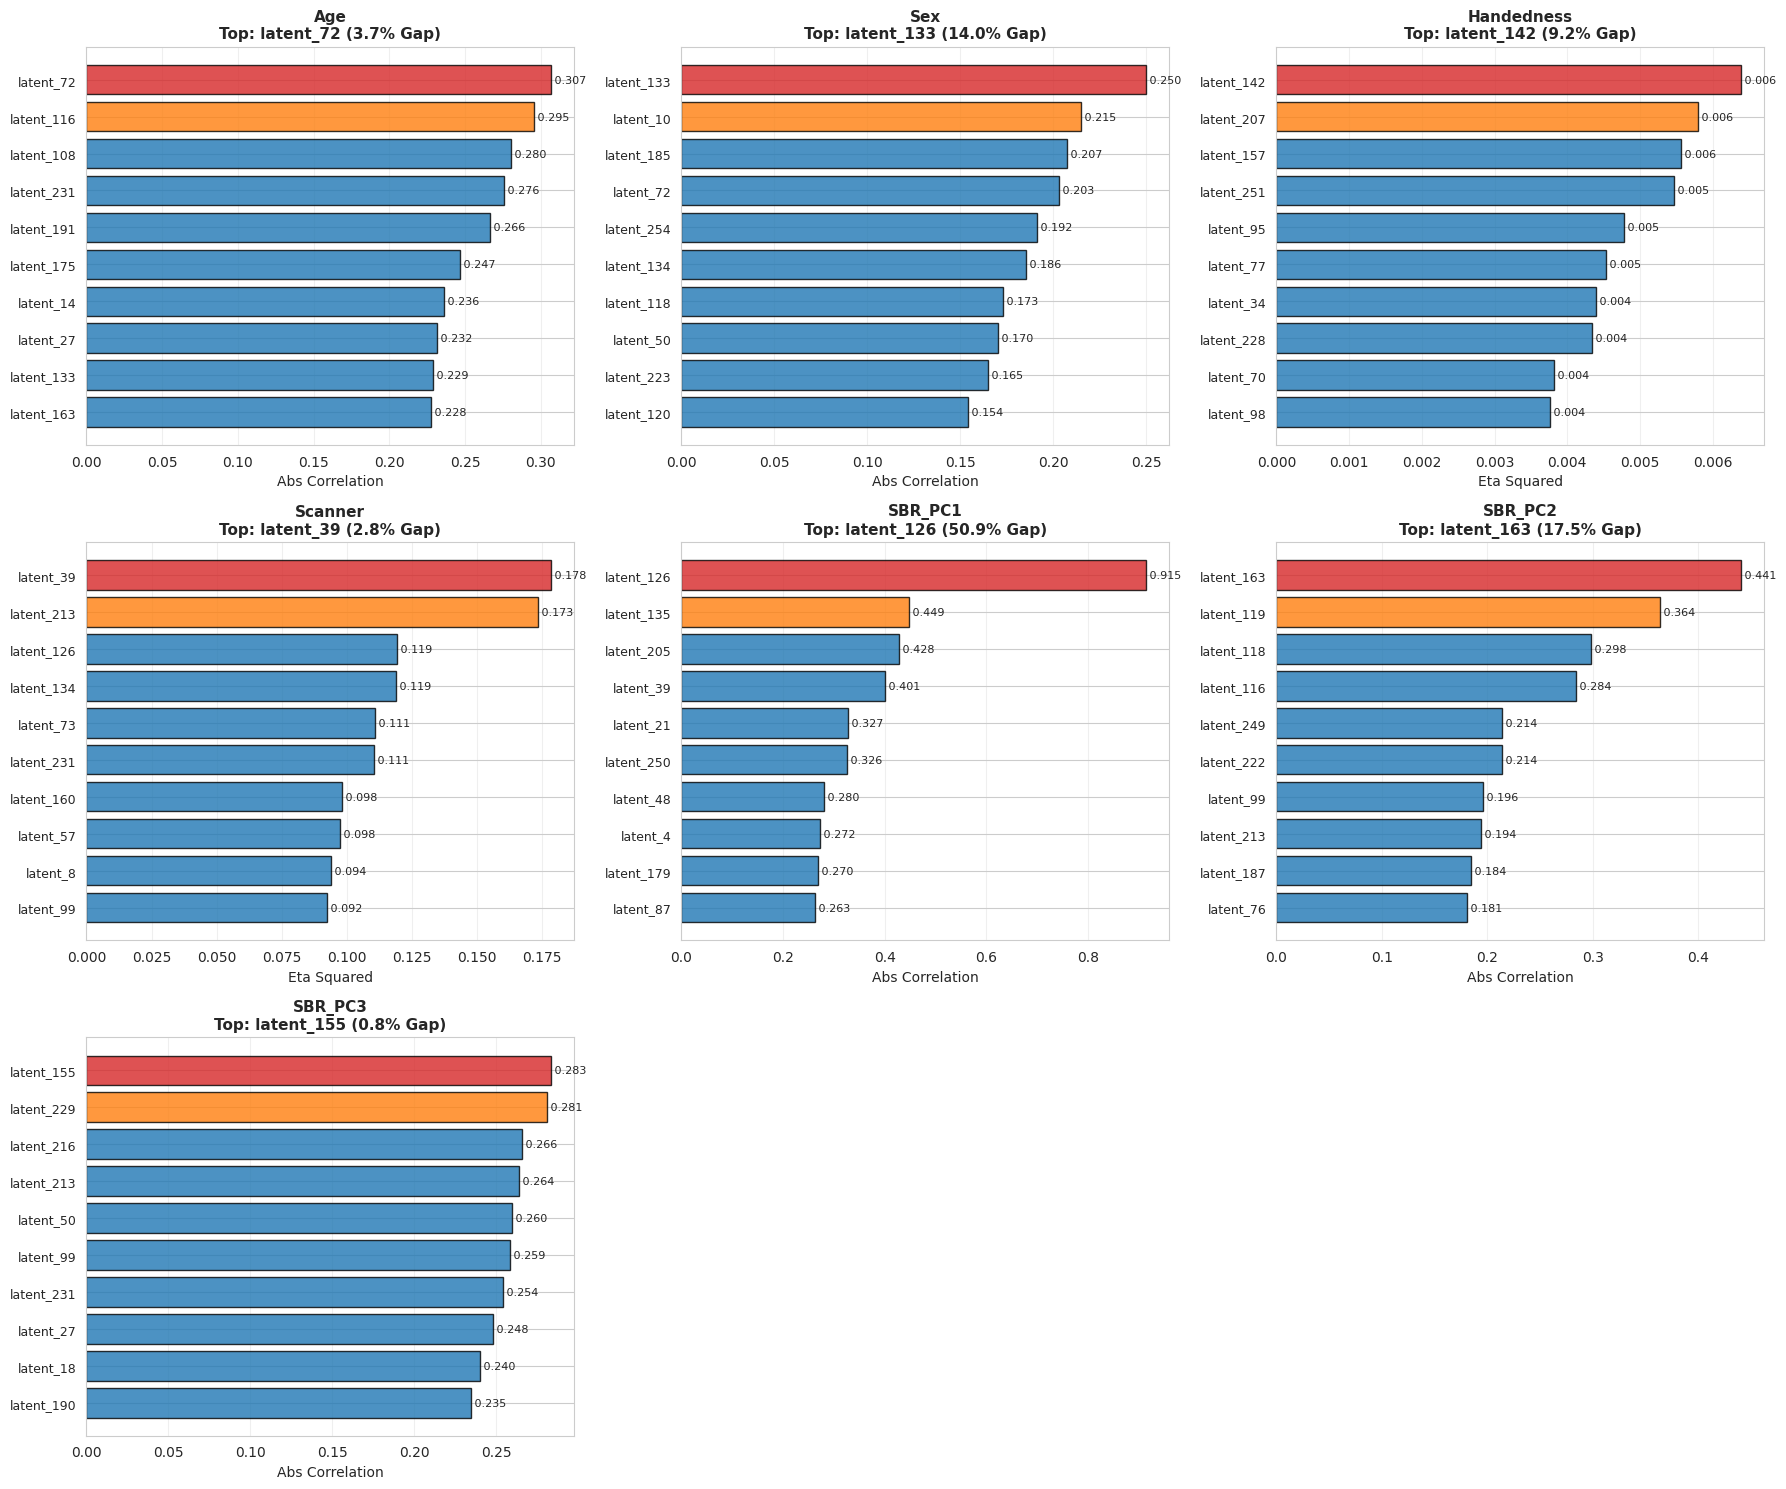

Plot saved to: output/dimension_factor_correlation_top10.png


In [23]:
fig, axes = plt.subplots(3, 3, figsize=(18, 15))
axes = axes.flatten()

# Prepare plot data using the new SBR dictionary structure
plot_data = [
    ('Age', df_age_corr, age_sep, 'Abs_Correlation'),
    ('Sex', df_sex_corr, sex_sep, 'Abs_Correlation'),
    ('Handedness', df_hand_corr, hand_sep, 'Eta_Squared' if df_hand_corr is not None and 'Eta_Squared' in df_hand_corr.columns else 'Abs_Correlation'),
    ('Scanner', df_scanner_corr, scanner_sep, 'Eta_Squared'),
]

# Dynamically add the SBR components from the dictionary
for pc in ['SBR_PC1', 'SBR_PC2', 'SBR_PC3']:
    if pc in sbr_results:
        plot_data.append((
            pc, 
            sbr_results[pc]['df_corr'], 
            sbr_results[pc]['sep_stats'], 
            'Abs_Correlation'
        ))

# Plot for each factor
for idx, (factor_name, df_corr, sep, metric_col) in enumerate(plot_data):
    # Skip if data is missing
    if df_corr is None or sep is None:
        axes[idx].text(0.5, 0.5, f'{factor_name}\nNo data', ha='center', va='center')
        continue
    
    # Get top 10
    top_10 = df_corr.head(10)
    
    # Create bar plot: Red for top, Orange for second, Blue for others
    colors = ['#d62728' if i == 0 else '#ff7f0e' if i == 1 else '#1f77b4' for i in range(len(top_10))]
    axes[idx].barh(range(len(top_10)), top_10[metric_col], color=colors, edgecolor='black', alpha=0.8)
    
    # Formatting
    axes[idx].set_yticks(range(len(top_10)))
    axes[idx].set_yticklabels(top_10['Feature'], fontsize=9)
    axes[idx].set_xlabel(metric_col.replace('_', ' '), fontsize=10)
    axes[idx].set_title(f'{factor_name}\nTop: {sep["Top_Feature"]} ({sep["Gap_Percent"]:.1f}% Gap)', 
                       fontsize=11, fontweight='bold')
    axes[idx].grid(True, alpha=0.3, axis='x')
    axes[idx].invert_yaxis()
    
    # Add labels on the bars
    for i, val in enumerate(top_10[metric_col]):
        axes[idx].text(val, i, f' {val:.3f}', va='center', fontsize=8)

# Remove any unused subplots (we have 9 slots and 7 plots)
for i in range(len(plot_data), len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.savefig('output/dimension_factor_correlation_top10.png', dpi=150, bbox_inches='tight')
plt.show()

print("Plot saved to: output/dimension_factor_correlation_top10.png")

### 4.3 Visualization: Separation Gap Comparison

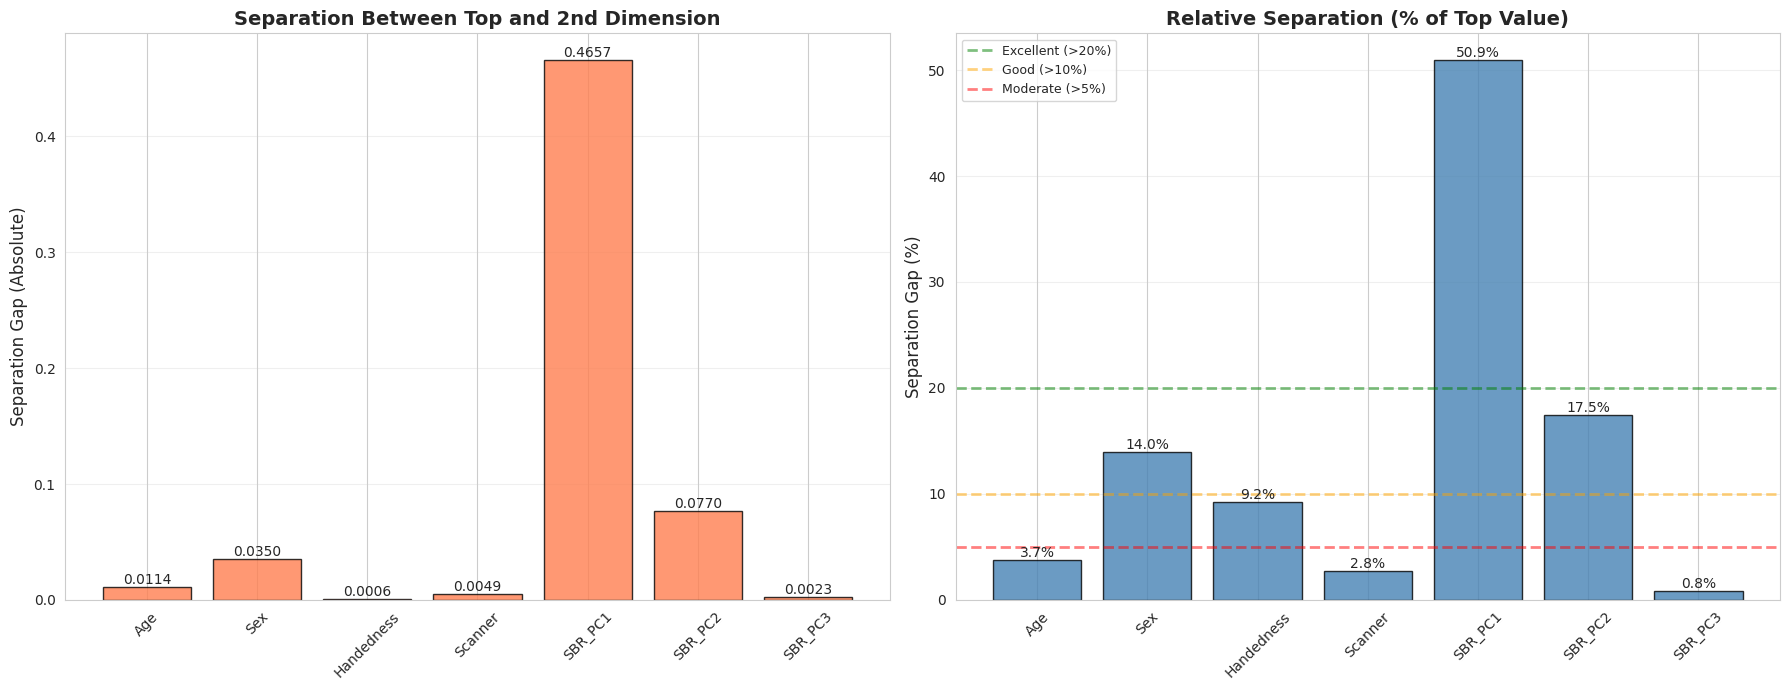

Plot saved to: output/dimension_factor_separation_gaps.png


In [24]:
# Increased width to 18 to accommodate the extra SBR categories
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Plot 1: Absolute gap
axes[0].bar(df_summary['Factor'], df_summary['Gap'], color='coral', edgecolor='black', alpha=0.8)
axes[0].set_ylabel('Separation Gap (Absolute)', fontsize=12)
axes[0].set_title('Separation Between Top and 2nd Dimension', fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3, axis='y')
axes[0].tick_params(axis='x', rotation=45) # Rotated labels are good for 7+ factors

# Add value labels
for i, gap in enumerate(df_summary['Gap']):
    axes[0].text(i, gap, f'{gap:.4f}', ha='center', va='bottom', fontsize=10)

# Plot 2: Relative gap (percentage)
axes[1].bar(df_summary['Factor'], df_summary['Gap_Percent'], color='steelblue', edgecolor='black', alpha=0.8)
axes[1].set_ylabel('Separation Gap (%)', fontsize=12)
axes[1].set_title('Relative Separation (% of Top Value)', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3, axis='y')
axes[1].tick_params(axis='x', rotation=45)

# Add value labels
for i, gap_pct in enumerate(df_summary['Gap_Percent']):
    axes[1].text(i, gap_pct, f'{gap_pct:.1f}%', ha='center', va='bottom', fontsize=10)

# Add threshold lines
axes[1].axhline(y=20, color='green', linestyle='--', linewidth=2, alpha=0.5, label='Excellent (>20%)')
axes[1].axhline(y=10, color='orange', linestyle='--', linewidth=2, alpha=0.5, label='Good (>10%)')
axes[1].axhline(y=5, color='red', linestyle='--', linewidth=2, alpha=0.5, label='Moderate (>5%)')

# Move legend outside or to a clean corner to avoid overlapping bars
axes[1].legend(fontsize=9, loc='upper left')

plt.tight_layout()
plt.savefig('output/dimension_factor_separation_gaps.png', dpi=150, bbox_inches='tight')
plt.show()

print("Plot saved to: output/dimension_factor_separation_gaps.png")

### 4.4 Visualization: Heatmap of Top Dimensions

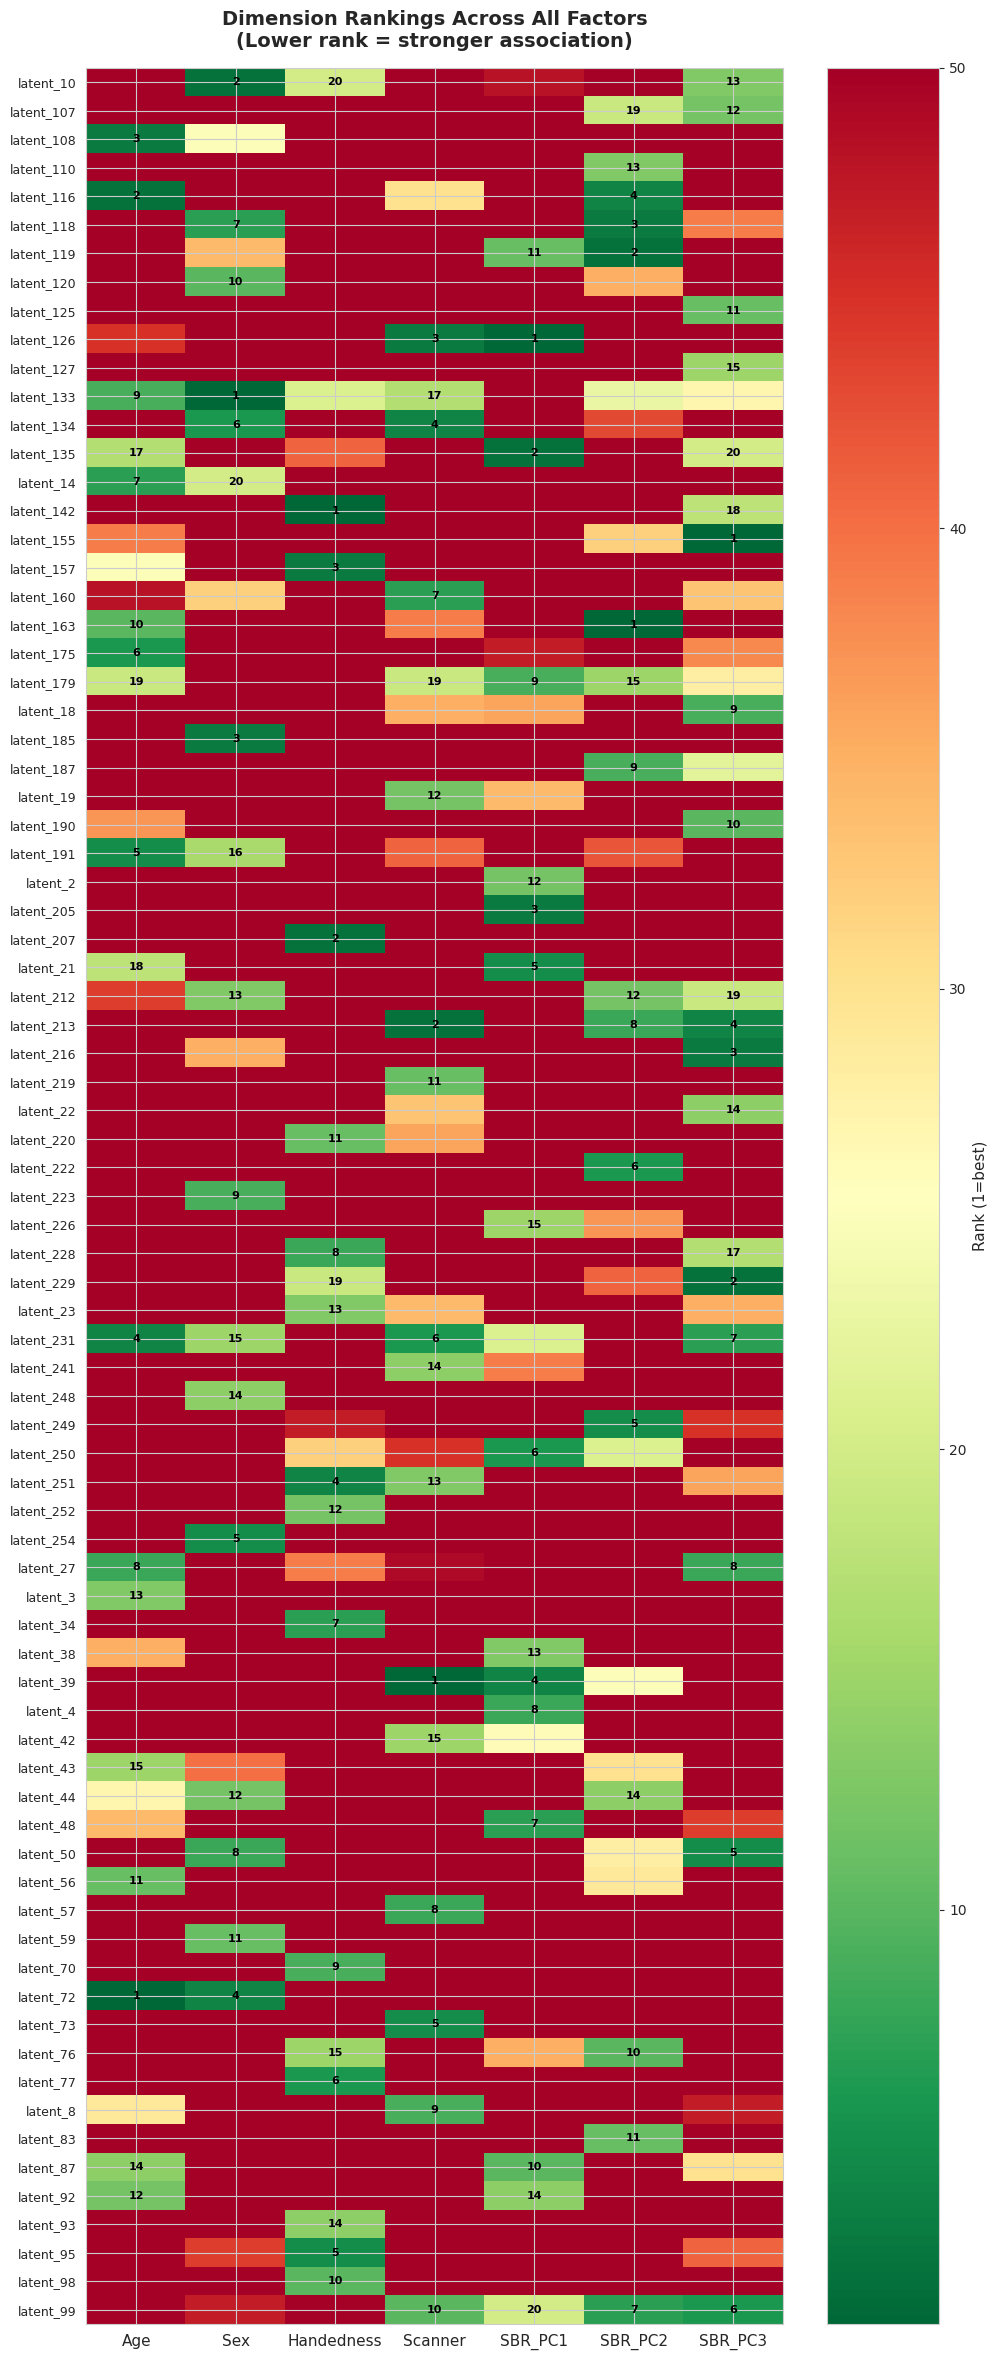

Plot saved to: output/dimension_factor_ranking_heatmap.png


In [25]:
# Create a matrix showing top dimensions for each factor
top_n_display = 15

# Collect all top dimensions
all_top_dims = set()
factor_rankings = {}

for factor_name, df_corr, sep, metric_col in plot_data:
    if df_corr is None:
        continue
    top_dims = df_corr.head(top_n_display)['Feature'].tolist()
    all_top_dims.update(top_dims)
    factor_rankings[factor_name] = {row['Feature']: row['Rank'] for _, row in df_corr.iterrows()}

all_top_dims = sorted(list(all_top_dims))

# Create ranking matrix
ranking_matrix = []
factor_names = [name for name, _, _, _ in plot_data if name in factor_rankings]

for dim in all_top_dims:
    row = []
    for factor_name in factor_names:
        rank = factor_rankings[factor_name].get(dim, 257)  # 257 if not in top rankings
        row.append(rank)
    ranking_matrix.append(row)

ranking_matrix = np.array(ranking_matrix)

# Create heatmap
fig, ax = plt.subplots(figsize=(10, max(8, len(all_top_dims) * 0.3)))

# Use reversed colormap so rank 1 is darkest
im = ax.imshow(ranking_matrix, cmap='RdYlGn_r', aspect='auto', vmin=1, vmax=50)

# Set ticks
ax.set_xticks(range(len(factor_names)))
ax.set_xticklabels(factor_names, fontsize=11)
ax.set_yticks(range(len(all_top_dims)))
ax.set_yticklabels(all_top_dims, fontsize=9)

# Add colorbar
cbar = plt.colorbar(im, ax=ax)
cbar.set_label('Rank (1=best)', fontsize=11)

# Add rank values to cells (only for top 20)
for i in range(len(all_top_dims)):
    for j in range(len(factor_names)):
        rank = ranking_matrix[i, j]
        if rank <= 20:
            text = ax.text(j, i, f'{int(rank)}',
                          ha="center", va="center", color="black", fontsize=8, fontweight='bold')

ax.set_title('Dimension Rankings Across All Factors\n(Lower rank = stronger association)', 
            fontsize=14, fontweight='bold', pad=15)

plt.tight_layout()
plt.savefig('output/dimension_factor_ranking_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

print("Plot saved to: output/dimension_factor_ranking_heatmap.png")

## Section 5: Save Results

### 5.1 Save Correlation Results

In [27]:
output_dir = Path('output')
output_dir.mkdir(exist_ok=True)

# 1. Save standard demographic/scanner correlations
df_age_corr.to_csv(output_dir / 'dimension_correlations_age.csv', index=False)
df_sex_corr.to_csv(output_dir / 'dimension_correlations_sex.csv', index=False)
if df_hand_corr is not None:
    df_hand_corr.to_csv(output_dir / 'dimension_correlations_handedness.csv', index=False)
df_scanner_corr.to_csv(output_dir / 'dimension_correlations_scanner.csv', index=False)

# 2. Save all SBR component correlations (PC1, PC2, PC3)
for pc_name, results in sbr_results.items():
    filename = f'dimension_correlations_{pc_name.lower()}.csv'
    results['df_corr'].to_csv(output_dir / filename, index=False)

# 3. Save the master summary
df_summary.to_csv(output_dir / 'dimension_factor_summary.csv', index=False)

print("Results saved to:")
print(f"  - {output_dir / 'dimension_correlations_age.csv'}")
print(f"  - {output_dir / 'dimension_correlations_sex.csv'}")
if df_hand_corr is not None:
    print(f"  - {output_dir / 'dimension_correlations_handedness.csv'}")
print(f"  - {output_dir / 'dimension_correlations_scanner.csv'}")

# Dynamic print for SBR files
for pc_name in sbr_results.keys():
    print(f"  - {output_dir / f'dimension_correlations_{pc_name.lower()}.csv'}")

print(f"  - {output_dir / 'dimension_factor_summary.csv'}")

Results saved to:
  - output/dimension_correlations_age.csv
  - output/dimension_correlations_sex.csv
  - output/dimension_correlations_handedness.csv
  - output/dimension_correlations_scanner.csv
  - output/dimension_correlations_sbr_pc1.csv
  - output/dimension_correlations_sbr_pc2.csv
  - output/dimension_correlations_sbr_pc3.csv
  - output/dimension_factor_summary.csv


### 5.2 Final Summary

In [26]:
print("\n" + "="*80)
print("ANALYSIS COMPLETE")
print("="*80)

print("\nKey Findings:")
print("-" * 80)

for _, row in df_summary.iterrows():
    quality = "EXCELLENT" if row['Gap_Percent'] > 20 else "GOOD" if row['Gap_Percent'] > 10 else "MODERATE" if row['Gap_Percent'] > 5 else "WEAK"
    
    print(f"\n{row['Factor']}:")
    print(f"  Top Dimension: {row['Top_Dimension']}")
    print(f"  {row['Metric']}: {row['Top_Value']:.4f}")
    print(f"  Separation: {quality} ({row['Gap_Percent']:.1f}% gap from 2nd-best)")
    print(f"  Statistical significance: p={row['P_Value']:.4e}")

print("\n" + "="*80)
print("All results and visualizations saved to output/ directory")
print("="*80)


ANALYSIS COMPLETE

Key Findings:
--------------------------------------------------------------------------------

Age:
  Top Dimension: latent_72
  Pearson r: 0.3068
  Separation: WEAK (3.7% gap from 2nd-best)
  Statistical significance: p=7.7602e-53

Sex:
  Top Dimension: latent_133
  Point-biserial r: 0.2500
  Separation: GOOD (14.0% gap from 2nd-best)
  Statistical significance: p=4.2107e-35

Handedness:
  Top Dimension: latent_142
  Eta²: 0.0064
  Separation: MODERATE (9.2% gap from 2nd-best)
  Statistical significance: p=5.0812e-04

Scanner:
  Top Dimension: latent_39
  Eta²: 0.1784
  Separation: WEAK (2.8% gap from 2nd-best)
  Statistical significance: p=2.1929e-89

SBR_PC1:
  Top Dimension: latent_126
  Pearson r: 0.9146
  Separation: EXCELLENT (50.9% gap from 2nd-best)
  Statistical significance: p=0.0000e+00

SBR_PC2:
  Top Dimension: latent_163
  Pearson r: 0.4407
  Separation: GOOD (17.5% gap from 2nd-best)
  Statistical significance: p=2.5081e-113

SBR_PC3:
  Top Dimensio